В данном файле проведен эксперимент по классификации новостных данных с использованием модели Логистической регресии. 
Метод векторизации - TF-IDF Standard
Файл больше тренировочный для меня. Сравнение методов векторизации происходит в файле 02.
Для визуализации результатов строится матрица ошибок. Также создается отчет по итогам классификации, который сохраняется в файле.

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Загрузка данных
data = fetch_20newsgroups(subset='all')
# тексты (строки)
X = data.data
# метки категорий (0-19)
y = data.target
# X[i]-текст, y[i]-категория текста

# # Размер датасета
# print(f"Количество документов: {len(X)}")
# print(f"Количество категорий: {len(data.target_names)}")
# print(f"Категории: {data.target_names}")

# # Первый документ
# print("\n=== Первый документ ===")
# print(X[0])

# # Метка первого документа
# print(f"\nКатегория первого документа: {data.target_names[y[0]]}")

In [3]:
# разделение: 20% на тест, 80 на обучение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# векторизация
# TfidfVectorizer превращает слова в числовой вектор, учитывая важность слова (TF-IDF)
# stop_words='english' → игнорируем "the", "and", "is" и т.п
vectorizer = TfidfVectorizer(stop_words='english')
# vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=10000)
# fit_transform(X_train) → обучаем векторизатор на тренировочных текстах и сразу получаем векторы
X_train_vec = vectorizer.fit_transform(X_train)
# transform(X_test) → превращаем тестовые тексты в векторы по уже обученному словарю
X_test_vec = vectorizer.transform(X_test)

In [5]:
# модель
model = LogisticRegression(max_iter=1000)
# fit → модель изучает зависимость между числами (векторами текста) и метками
model.fit(X_train_vec, y_train)
# Теперь модель умеет предсказывать категорию по тексту.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
# предсказание
# Модель смотрит на тестовые векторы и выдаёт предсказанную категорию для каждого текста
y_pred = model.predict(X_test_vec)

# Сравниваем, сколько предсказаний совпало с реальными метками
# accuracy_score = (правильные предсказания) / (всего тестовых примеров)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
report = classification_report(y_test, y_pred, target_names = data.target_names)
print(report)
# 17+45

0.8994694960212202
                          precision    recall  f1-score   support

             alt.atheism       0.88      0.89      0.88       151
           comp.graphics       0.79      0.87      0.83       202
 comp.os.ms-windows.misc       0.83      0.83      0.83       195
comp.sys.ibm.pc.hardware       0.72      0.76      0.74       183
   comp.sys.mac.hardware       0.90      0.86      0.88       205
          comp.windows.x       0.89      0.85      0.87       215
            misc.forsale       0.84      0.83      0.83       193
               rec.autos       0.91      0.94      0.92       196
         rec.motorcycles       0.97      0.93      0.95       168
      rec.sport.baseball       0.97      0.97      0.97       211
        rec.sport.hockey       0.96      0.97      0.97       198
               sci.crypt       0.98      0.95      0.96       201
         sci.electronics       0.86      0.87      0.86       202
                 sci.med       0.95      0.96      0.96 

In [9]:
# Создаем словарь из отчета
report_dict = classification_report(y_test, y_pred, target_names=data.target_names, output_dict=True)

# Превращаем в красивую таблицу
df_report = pd.DataFrame(report_dict).transpose()

# Выводим (в Jupyter это будет выглядеть как аккуратная таблица)
df_report_sorted = df_report.sort_values(by='f1-score')
# Сохраняем твою таблицу с метриками
import os
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/plots", exist_ok=True)
df_report_sorted.to_csv('../results/tables/tfidf_logistic_results.csv')

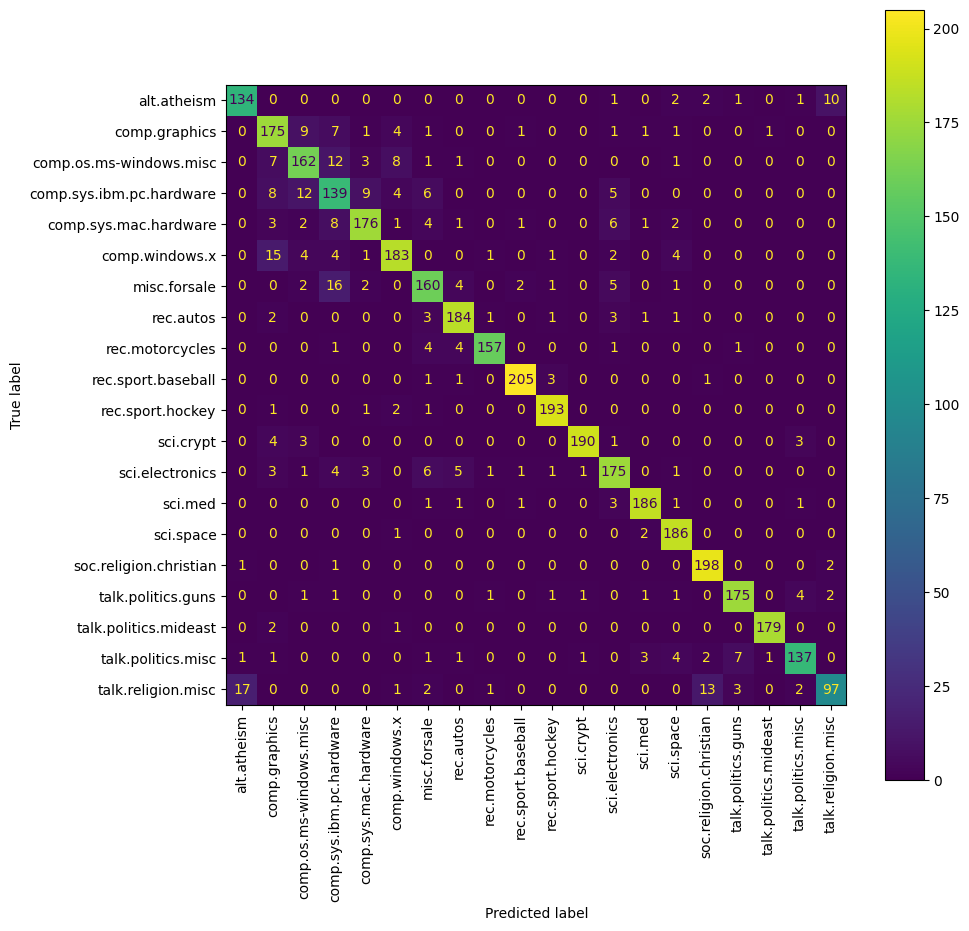

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_estimator(model, X_test_vec, y_test, 
                                      display_labels=data.target_names, 
                                      xticks_rotation='vertical', ax=ax)
plt.savefig('../results/plots/confusion_matrix_baseline.png')
plt.show()

По вертикали (ось Y): Это правильные ответы (какой тема была на самом деле).
По горизонтали (ось X): Это то, что предсказала твоя модель.
Диагональ (от левого верхнего угла в правый нижний): Это твои «пятерки». Чем ярче и больше числа на этой линии, тем круче работает модель. Это случаи, когда реальность совпала с предсказанием.
Смотри на числа вне главной диагонали.
Например, найди строчку sci.electronics и посмотри, есть ли числа в колонке sci.med.
Если там стоит, скажем, «3», значит модель 3 разf перепутала электронику с медициной.

Для диплома это золото! Ты пишешь: «Анализ матрицы ошибок показал, что модель часто путает категорию А с категорией Б. Это объясняется наличием общей терминологии (например, медицинское оборудование упоминается в обеих темах)».

17 текстов, которые на самом деле были про атеизм (alt.atheism), 
модель ошибочно классифицировала как «разные религиозные дискуссии» (talk.religion.misc).

В разделе 3.4 «Обсуждение результатов» ты можешь использовать этот пример, чтобы показать глубокое понимание работы алгоритмов:
Семантическая близость: Ты пишешь, что высокая степень ошибок между этими категориями вызвана схожестью словаря. 
    И в атеистических, и в религиозных текстах часто встречаются одни и те же токены (слова): god, belief, bible, moral, religion.
Проблема метода векторизации (TF-IDF): Поскольку TF-IDF (который ты использовала) считает только частоту слов, он не понимает контекста.
    Для него предложение «Я верю в Бога» и «Я не верю в Бога» выглядят почти одинаково, так как ключевые слова совпадают.
Обоснование для сравнения: Именно поэтому в следующей главе ты предложишь 
использовать более современные методы (например, Word2Vec или BERT), 
которые умеют различать контекст и смысл, а не просто считать слова.